# 03 - Data Preparation: Sampling & Statistical Checks
---
This notebook is used to determine how large should be the size of the sampling that will be used in the modeling phase of the KDD process.

It is also used to check and statistically compare the sampled dataset with the original ones, in order to ensure that both size and representation are preserved.

## Import libraries and settings

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from fraud_dynamic_ensemble.config import EXTERNAL_DATA_DIR, EXTERNAL_FILENAME, RAW_DATA_DIR, RAW_FILENAME, FIGURES_DIR
from fraud_dynamic_ensemble.evaluation.statistical_test_evaluation import ks_two_sample

2026-02-02 18:07:08.463 | INFO     | fraud_dynamic_ensemble.config:<module>:14 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
original_path : Path = EXTERNAL_DATA_DIR / EXTERNAL_FILENAME
sampled_path : Path = RAW_DATA_DIR / RAW_FILENAME
print(f"Loading ORIGINAL dataset at path:\n\t{original_path}")
print(f"Loading SAMPLED dataset at path:\n\t{sampled_path}")

Loading ORIGINAL dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/external/creditcardfraud.csv
Loading SAMPLED dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/raw/credit_card_fraud_sampling.csv


In [3]:
FIGURES_SAMPLING_CHECKS_DIR = FIGURES_DIR / "DP_sampling_checks"
FIGURES_SAMPLING_CHECKS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sns.set_style("whitegrid")
sns.set_palette("tab10")
plt.rcParams.update({"font.size": 16})

In [5]:
df_before = pd.read_csv(original_path, header=0, sep=",")
print(f"ORIGINAL Dataset dimension\n"
      f"\t-Number of rows = {df_before.shape[0]}\n"
      f"\t-Number of cols = {df_before.shape[1]}")

ORIGINAL Dataset dimension
	-Number of rows = 284807
	-Number of cols = 31


In [6]:
df_after = pd.read_csv(sampled_path, header=0, sep=",")
print(f"SAMPLED Dataset dimension\n"
      f"\t-Number of rows = {df_after.shape[0]}\n"
      f"\t-Number of cols = {df_after.shape[1]}")

SAMPLED Dataset dimension
	-Number of rows = 2952
	-Number of cols = 31


## Class Balance
Visualize the class imbalance comparing the original dataset and the sampled dataset.


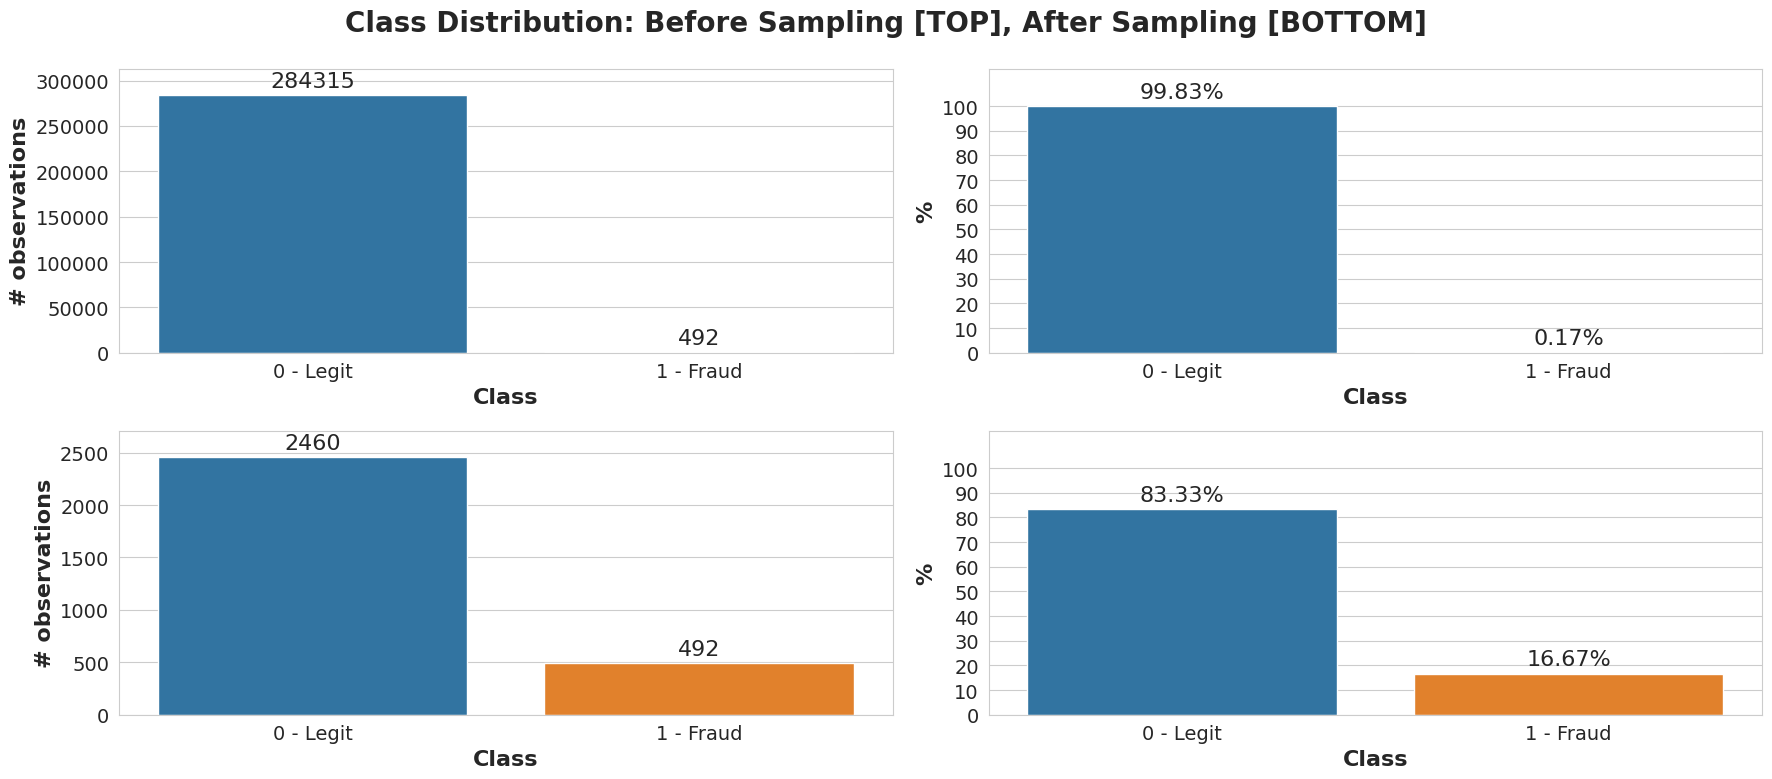

In [7]:
###### BEFORE SAMPLING ######
class_counts_before = df_before["Class"].value_counts().sort_index()
total = class_counts_before.sum()
class_percentages = class_counts_before / total * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# ------- Subplot 1: Counting the observations per class
sns.countplot(ax=axes[0,0], data=df_before, x="Class", hue="Class", legend=False)
axes[0,0].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[0,0].set_ylabel("# observations", fontweight="bold", fontsize=16)
axes[0,0].set_xticks(ticks=[0, 1], labels=["0 - Legit", "1 - Fraud"], fontsize=14)
axes[0,0].set_yticks(ticks=np.arange(0, 320000, 50000),
                     labels=np.arange(0, 320000, 50000),
                     fontsize=14)

for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt="%.0f", padding=3)

axes[0,0].margins(y=0.1) # Avoid clipping labels at the top

# ------- Subplot 2: Percentage per class
sns.barplot(ax=axes[0,1],
            x=class_percentages.index.astype(str),
            y=class_percentages.values,
            hue=class_percentages.index.astype(str))
axes[0,1].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[0,1].set_ylabel("%", fontweight="bold", fontsize=16)
axes[0,1].set_xticks(ticks=[0, 1], labels=["0 - Legit", "1 - Fraud"], fontsize=14)
axes[0,1].set_yticks(ticks=np.arange(0, 110, 10),
                     labels=np.arange(0, 110, 10),
                     fontsize=14)
axes[0,1].set_ylim([0, 115])

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt="%.2f%%", padding=3)

axes[0,1].margins(y=0.1)

###### AFTER SAMPLING ######
class_counts_after = df_after["Class"].value_counts().sort_index()
total = class_counts_after.sum()
class_percentages = class_counts_after / total * 100

# ------- Subplot 3: Counting the observations per class
sns.countplot(ax=axes[1,0], data=df_after, x="Class", hue="Class", legend=False)
axes[1,0].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[1,0].set_ylabel("# observations", fontweight="bold", fontsize=16)
axes[1,0].set_xticks(ticks=[0, 1], labels=["0 - Legit", "1 - Fraud"], fontsize=14)
axes[1,0].set_yticks(ticks=np.arange(0, 2600, 500),
                     labels=np.arange(0, 2600, 500),
                     fontsize=14)

for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt="%.0f", padding=3)

axes[1,0].margins(y=0.1) # Avoid clipping labels at the top

# ------- Subplot 4: Percentage per class
sns.barplot(ax=axes[1,1],
            x=class_percentages.index.astype(str),
            y=class_percentages.values,
            hue=class_percentages.index.astype(str))
axes[1,1].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[1,1].set_ylabel("%", fontweight="bold", fontsize=16)
axes[1,1].set_xticks(ticks=[0, 1], labels=["0 - Legit", "1 - Fraud"], fontsize=14)
axes[1,1].set_yticks(ticks=np.arange(0, 110, 10),
                     labels=np.arange(0, 110, 10),
                     fontsize=14)
axes[1,1].set_ylim([0, 115])

for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt="%.2f%%", padding=3)

axes[1,1].margins(y=0.1)

# ------- General settings
plt.suptitle("Class Distribution: Before Sampling [TOP], After Sampling [BOTTOM]", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "class_distribution_absolute_vs_percentage.png", dpi=300)
plt.show()

Since we pick all the samples of the fraud class (1), the next steps focus only on the class (0).

In [8]:
df_before_legit = df_before[df_before["Class"] == 0]
df_before_legit.insert(0, "Sampled", "Before")
df_before_legit.head()

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,Before,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,Before,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,Before,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,Before,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,Before,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df_after_legit = df_after[df_after["Class"] == 0]
df_after_legit.insert(0, "Sampled", "After")
df_after_legit.head()

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,After,135520.0,-0.620780,1.110252,-0.542247,-0.880247,0.570118,-0.807532,1.085091,0.250780,-0.699077,-0.559393,0.105994,0.565050,-0.466575,0.838976,-1.610309,-0.162761,-0.359823,-0.036279,0.445460,-0.068099,0.111933,0.351654,-0.145909,-0.282311,-0.155981,0.597454,0.181561,0.150043,38.31,0
1,After,51507.0,-1.302336,1.016359,1.007046,-0.127051,0.435740,-0.092143,0.709650,0.590142,-1.088295,-0.861652,0.710128,0.155672,-1.156248,1.063444,-0.131576,0.233566,-0.427107,0.128870,-0.700723,-0.174480,0.150091,0.059446,-0.262177,-0.354871,0.680078,-0.402172,-0.111834,-0.044427,51.59,0
2,After,31312.0,1.321432,-0.356293,0.300205,0.201982,-0.208365,0.743361,-0.656105,0.070828,-0.881980,0.750478,-1.483939,0.176419,1.918991,-0.344681,1.283988,-0.989078,-0.660943,1.393825,-1.232635,-0.388459,-0.281173,-0.243962,-0.163223,-1.324377,0.537850,-0.189712,0.088370,0.026635,30.00,0
3,After,135187.0,0.295894,0.996365,-1.100069,-0.709061,0.819519,-0.649214,0.621989,0.140711,-0.217537,-0.767588,-1.348711,0.700200,1.518120,0.353130,0.104784,0.097713,-0.811065,0.137814,-0.347555,-0.243652,0.364834,1.073405,-0.090512,0.294868,-0.288911,-0.281174,-0.063834,-0.047913,0.74,0
4,After,74284.0,1.236053,0.286630,0.186867,0.501575,-0.163476,-0.562945,-0.030210,-0.029673,-0.188527,-0.110280,1.320676,0.758435,0.091882,-0.089292,0.429253,0.775740,-0.369263,0.316460,0.215519,-0.065490,-0.258603,-0.786773,0.077436,-0.039847,0.226115,0.097651,-0.028057,0.017120,1.98,0


In [10]:
df_compare = pd.concat([df_before_legit, df_after_legit], axis=0, ignore_index=True)
df_compare.head(5)

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,Before,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,Before,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,Before,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,Before,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,Before,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df_compare.tail(5)

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
286770,After,45973.0,1.169614,-0.665872,-0.041983,-0.359849,-0.812717,-0.588994,-0.442513,-0.061559,-0.583560,0.048756,0.014180,-0.713697,-0.339282,-1.234593,0.365153,0.846414,1.611205,-1.637376,0.282134,0.217954,-0.002330,-0.172297,-0.057024,0.006988,0.358057,-0.280263,0.018903,0.049752,102.96,0
286771,After,166186.0,2.039524,0.584622,-2.531259,0.542936,0.889901,-1.196265,0.317948,-0.279874,0.158943,-1.053340,1.607238,0.729494,0.784013,-2.526715,0.316146,1.068610,1.299858,1.822088,-0.234914,-0.075654,0.127139,0.575983,-0.128512,-0.685031,0.318704,-0.093277,0.020951,-0.005431,1.00,0
286772,After,158550.0,0.063699,0.146512,0.843741,-0.532952,-0.006310,-0.219382,0.293402,0.133295,0.715520,-0.857106,-1.135876,-0.151231,-0.539067,-0.090549,0.344905,0.358771,-0.686359,0.050479,-0.348673,-0.068855,-0.129309,-0.496561,0.263994,0.653535,-0.305080,-0.688665,-0.040553,-0.065335,54.99,0
286773,After,64741.0,1.237285,0.695662,-0.353485,1.355507,0.047586,-1.254264,0.284145,-0.222093,-0.028516,-0.669460,0.054414,-0.334854,-0.472011,-1.254125,1.134635,0.615591,0.918108,0.643007,-0.622807,-0.124456,-0.072452,-0.155734,-0.118596,0.240849,0.677133,-0.326026,0.032552,0.056618,1.00,0
286774,After,164776.0,1.947737,0.009899,-1.244776,1.302383,0.040133,-1.067379,0.301814,-0.311473,0.330881,0.328189,-0.865231,-0.142368,-0.600555,0.643363,0.646478,-0.061264,-0.526809,-0.009001,-0.695012,-0.237873,0.279370,0.832769,-0.026910,-0.020475,0.268850,-0.425449,-0.005599,-0.046730,42.80,0


## Comparing Amount Distribution

Let's first compare very quickly some basic statistics for `Amount`.

In [12]:
df_compare.groupby("Sampled", observed=True)["Amount"].describe().sort_values(by="Sampled", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Sampled,,,,,,,,
Before,284315.0,88.291022,250.105092,0.0,5.6500,22.0,77.05,25691.16
After,2460.0,85.481882,212.213059,0.0,5.0375,22.0,74.95,4000.00


In [13]:
df_compare.groupby("Sampled", observed=True)["Amount"].skew().sort_index(ascending=False)

Sampled
Before    17.003147
After      7.170440
Name: Amount, dtype: float64

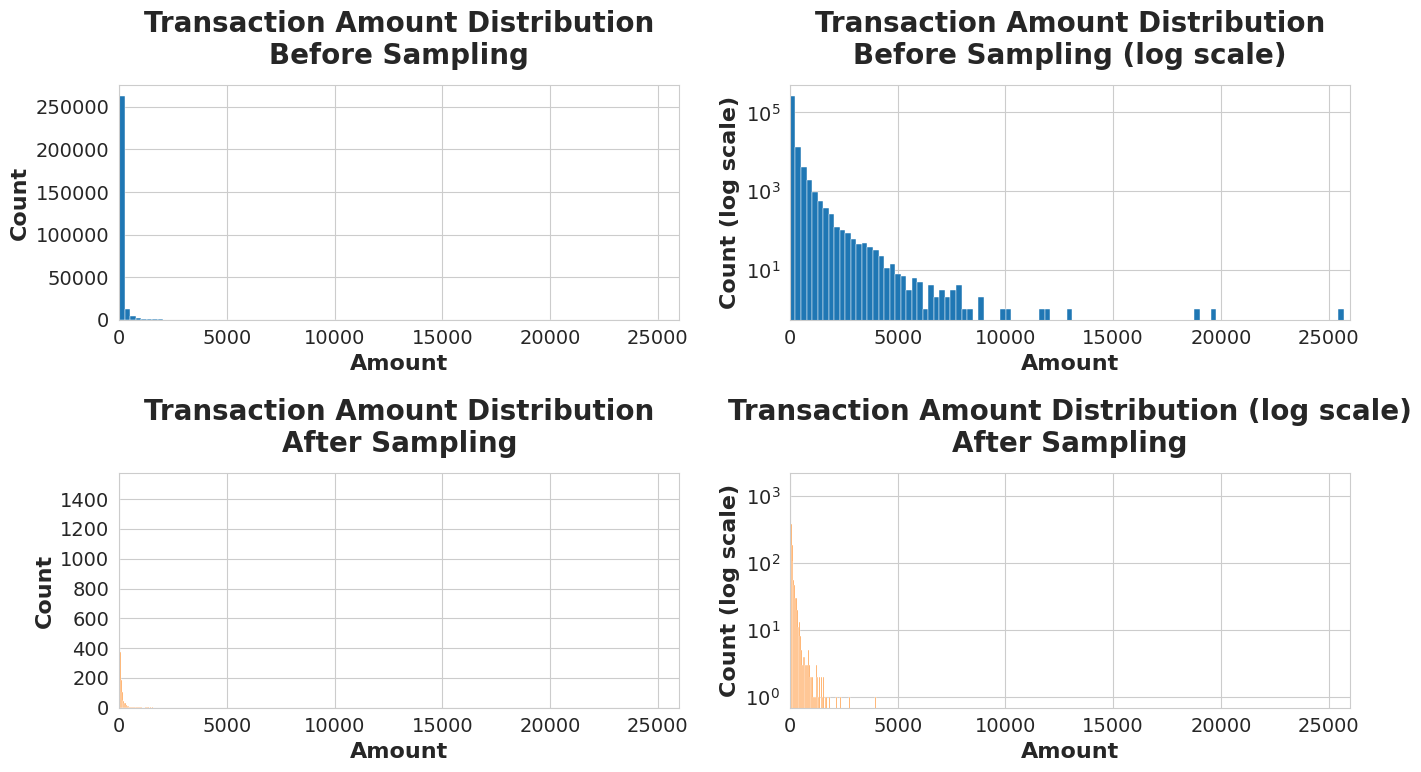

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ------- Transaction Amount Distribution BEFORE SAMPLING
sns.histplot(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             fill=True,
             ax=axes[0,0])
axes[0,0].set_xlim(0, 26000)
axes[0,0].set_xlabel("Amount", fontweight="bold", fontsize=16)
axes[0,0].set_ylabel("Count", fontweight="bold", fontsize=16)
axes[0,0].set_xticks(ticks=np.arange(0, 26000, 5000),
                     labels=np.arange(0, 26000, 5000),
                     fontsize=14
                     )
axes[0,0].set_yticks(ticks=np.arange(0, 280000, 50000),
                     labels=np.arange(0, 280000, 50000),
                     fontsize=14
                     )
axes[0,0].set_title("Transaction Amount Distribution\nBefore Sampling",
                    fontsize=20,
                    fontweight="bold",
                    pad=15
                    )

# ------- Transaction Amount Distribution BEFORE SAMPLING (log-scale)
sns.histplot(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0,1])
axes[0,1].set_xlim(0, 26000)
axes[0,1].set_xlabel("Amount", fontweight="bold", fontsize=16)
axes[0,1].set_ylabel("Count (log scale)", fontweight="bold", fontsize=16)
axes[0,1].set_xticks(ticks=np.arange(0, 26000, 5000),
                     labels=np.arange(0, 26000, 5000),
                     fontsize=14
                     )
axes[0,1].set_yticks(ticks=np.arange(0, 280000, 50000),
                     labels=np.arange(0, 280000, 50000),
                     fontsize=14
                     )
axes[0,1].set_yscale("log")
axes[0,1].set_title("Transaction Amount Distribution\nBefore Sampling (log scale)",
                    fontsize=20,
                    fontweight="bold",
                    pad=15
                    )

# ------- Transaction Amount Distribution AFTER SAMPLING
sns.histplot(df_compare[df_compare["Sampled"] == "After"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,0])
axes[1,0].set_xlim(0, 26000)
axes[1,0].set_xlabel("Amount", fontweight="bold", fontsize=16)
axes[1,0].set_ylabel("Count", fontweight="bold", fontsize=16)
axes[1,0].set_xticks(ticks=np.arange(0, 26000, 5000),
                     labels=np.arange(0, 26000, 5000),
                     fontsize=14
                     )
axes[1,0].set_yticks(ticks=np.arange(0, 1600, 200),
                     labels=np.arange(0, 1600, 200),
                     fontsize=14
                    )
axes[1,0].set_title("Transaction Amount Distribution\nAfter Sampling",
                    fontsize=20,
                    fontweight="bold",
                    pad=15
                    )

# ------- Transaction Amount Distribution AFTER SAMPLING (log-scale)
sns.histplot(df_compare[df_compare["Sampled"] == "After"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,1])
axes[1,1].set_xlim(0, 26000)
axes[1,1].set_xlabel("Amount", fontweight="bold", fontsize=16)
axes[1,1].set_ylabel("Count (log scale)", fontweight="bold", fontsize=16)
axes[1,1].set_xticks(ticks=np.arange(0, 26000, 5000),
                     labels=np.arange(0, 26000, 5000),
                     fontsize=14
                     )
axes[1,1].set_yticks(ticks=np.arange(0, 1600, 200),
                     labels=np.arange(0, 1600, 200),
                     fontsize=14
                     )
axes[1,1].set_yscale("log")
axes[1,1].set_title("Transaction Amount Distribution (log scale)\nAfter Sampling",
                    fontsize=20,
                    fontweight="bold",
                    pad=15
                    )

# ------- General settings
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "amount_distribution_log_scale_by_class.png", dpi=300)
plt.show()

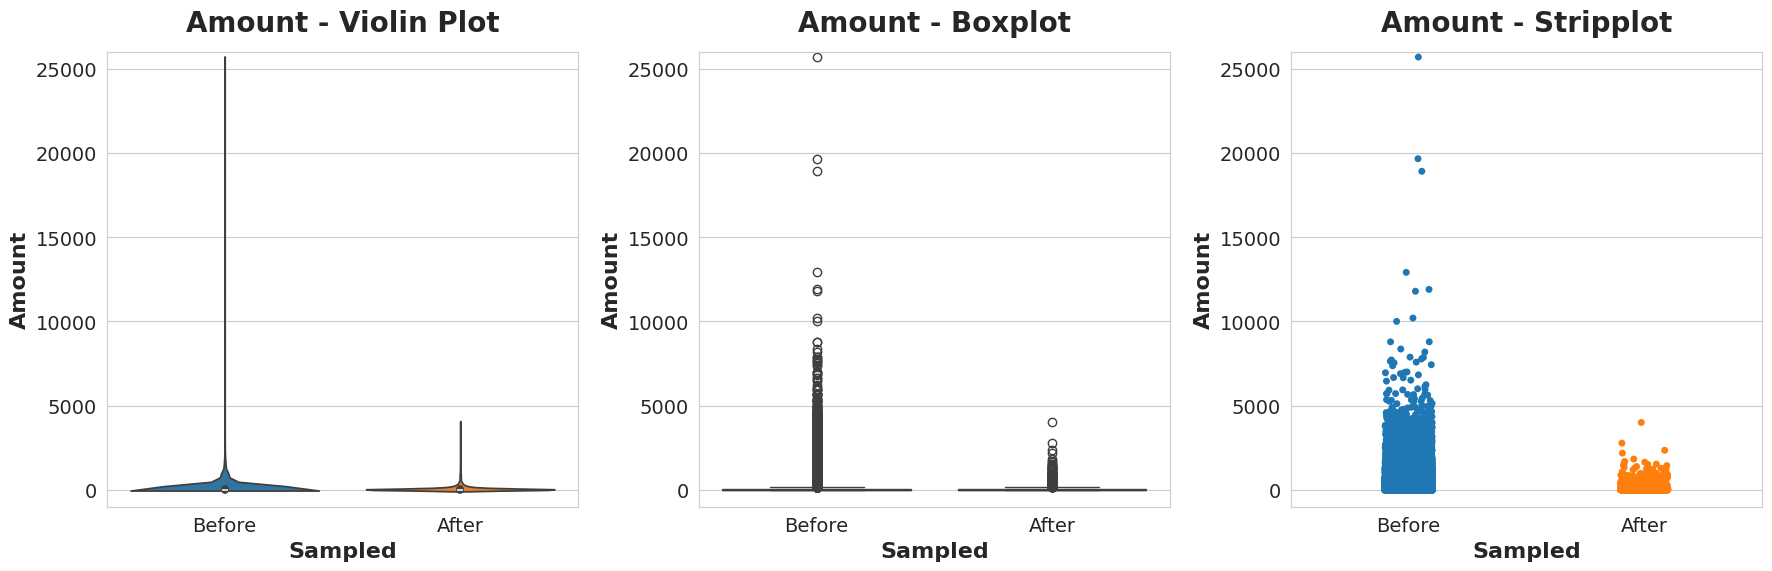

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.violinplot(data=df_compare,
               x="Sampled",
               y="Amount",
               hue="Sampled",
               ax=axes[0],
               legend=False)
axes[0].set_ylim(-1000, 26000)
axes[0].set_xlabel("Sampled", fontweight="bold", fontsize=16)
axes[0].set_ylabel("Amount", fontweight="bold", fontsize=16)
axes[0].set_xticks(ticks=[0, 1],
                   labels=["Before", "After"],
                   fontsize=14
                   )
axes[0].set_yticks(ticks=np.arange(0, 26000, 5000),
                   labels=np.arange(0, 26000, 5000),
                   fontsize=14
                    )
axes[0].set_title("Amount - Violin Plot",
                  fontsize=20,
                  fontweight="bold",
                  pad=15
                  )

sns.boxplot(data=df_compare,
            x="Sampled",
            y="Amount",
            hue="Sampled",
            ax=axes[1],
            legend=False)
axes[1].set_ylim(-1000, 26000)
axes[1].set_xlabel("Sampled", fontweight="bold", fontsize=16)
axes[1].set_ylabel("Amount", fontweight="bold", fontsize=16)
axes[1].set_xticks(ticks=[0, 1],
                   labels=["Before", "After"],
                   fontsize=14
                   )
axes[1].set_yticks(ticks=np.arange(0, 26000, 5000),
                   labels=np.arange(0, 26000, 5000),
                   fontsize=14
                    )
axes[1].set_title("Amount - Boxplot",
                  fontsize=20,
                  fontweight="bold",
                  pad=15
                  )

sns.stripplot(data=df_compare,
              x="Sampled",
              y="Amount",
              hue="Sampled",
              ax=axes[2],
              legend=False)
axes[2].set_ylim(-1000, 26000)
axes[2].set_xlabel("Sampled", fontweight="bold", fontsize=16)
axes[2].set_ylabel("Amount", fontweight="bold", fontsize=16)
axes[2].set_xticks(ticks=[0, 1],
                   labels=["Before", "After"],
                   fontsize=14
                   )
axes[2].set_yticks(ticks=np.arange(0, 26000, 5000),
                   labels=np.arange(0, 26000, 5000),
                   fontsize=14
                    )
axes[2].set_title("Amount - Stripplot",
                  fontsize=20,
                  fontweight="bold",
                  pad=15
                  )

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "amount_violin_box_strip_plot.png", dpi=300)
plt.show()

In [16]:
out = ks_two_sample(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
                    df_compare[df_compare["Sampled"] == "After"]["Amount"])
print(f"KS D={out['D']:.4f}, p={out['p']:.3e} (n_x={out['n_x']}, n_y={out['n_y']})")

KS D=0.0111, p=9.236e-01 (n_x=284315, n_y=2460)


The K-S test's null hypothesis ($H_0$) is that both samples (your population and your new sample) are drawn from the same distribution.

The Test: We compare the p-value to a significance level ($\alpha = 0.05$).

Interpretation: The returned p-value (0.9236) is much, much larger than 0.05. When the p-value is high, we fail to reject the null hypothesis.

We have no statistical evidence to say that the two distributions are different. We can assume they are the same. This is especially powerful given your large sample sizes. Large samples are very sensitive and can often find tiny, statistically significant (but practically meaningless) differences. The fact that this test still found no significant difference is a very strong positive

---

The K-S Statistic (D = 0.0111) confirms the p-value's result. The D statistic measures the maximum difference between the two cumulative distribution curves. A value of 0.0111 suggests that the distributions are nearly identical.

## Comparing PCA Feature (V1-V28) Distribution

In [17]:
pcs_cols_name = [f"V{i}" for i in range(1, 29)]

# Melt the DataFrame to a long format. This stacks all V1...V28 columns into two columns:
# 'Feature' (with values like 'V1', 'V2') and 'Value'
df_melted = df_compare.melt(id_vars=["Sampled"],
                            value_vars=pcs_cols_name,
                            var_name="Feature",
                            value_name="Value")

# Group by 'Feature' first, then 'Sampled', and get stats
df_melted.groupby(["Feature", "Sampled"])["Value"].describe()

count      mean       std         min       25%       50%  \
Feature Sampled                                                                 
V1      After      2460.0 -0.011051  1.995458  -26.389030 -0.924532  0.016904   
        Before   284315.0  0.008258  1.929814  -56.407510 -0.917544  0.020023   
V10     After      2460.0  0.015927  1.013345   -6.516183 -0.522431 -0.095457   
        Before   284315.0  0.009824  1.044204  -14.741096 -0.532880 -0.091872   
V11     After      2460.0  0.014884  1.005825   -2.699865 -0.756753  0.009931   
        Before   284315.0 -0.006576  1.003112   -4.797473 -0.763447 -0.034923   
V12     After      2460.0  0.025777  0.943124   -7.168570 -0.384826  0.161502   
        Before   284315.0  0.010832  0.945939  -15.144988 -0.402102  0.141679   
V13     After      2460.0  0.021104  0.989193   -3.303923 -0.623490  0.015120   
        Before   284315.0  0.000189  0.995067   -5.791881 -0.648067 -0.013547   
V14     After      2460.0  0.000089  0.935287   -8.516166 -0.421452  0.050153   
        Before   284315.0  0.012064  0.897007  -18.392091 -0.422453  0.051947   
V15     After      2460.0  0.002813  0.915196   -3.490033 -0.607085  0.034922   
        Before   284315.0  0.000161  0.915060   -4.391307 -0.582812  0.048294   
V16     After      2460.0  0.004231  0.842155   -4.793078 -0.475646  0.052965   
        Before   284315.0  0.007164  0.844772  -10.115560 -0.465543  0.067377   
V17     After      2460.0  0.029226  0.743314   -7.958642 -0.483062 -0.066770   
        Before   284315.0  0.011535  0.749457  -17.098444 -0.482644 -0.064833   
V18     After      2460.0 -0.003565  0.838272   -3.696550 -0.523743  0.011000   
        Before   284315.0  0.003887  0.824919   -5.366660 -0.497414 -0.002787   
V19     After      2460.0  0.042823  0.794512   -2.906500 -0.415380  0.043062   
        Before   284315.0 -0.001178  0.811733   -7.213527 -0.456366  0.003117   
V2      After      2460.0 -0.047870  1.700042  -29.336007 -0.619958  0.056290   
        Before   284315.0 -0.006271  1.636146  -72.715728 -0.599473  0.064070   
V20     After      2460.0 -0.004125  0.809856  -18.757060 -0.216867 -0.064173   
        Before   284315.0 -0.000644  0.769404  -54.497720 -0.211764 -0.062646   
V21     After      2460.0  0.002640  0.708693  -14.045185 -0.232281 -0.025508   
        Before   284315.0 -0.001235  0.716743  -34.830382 -0.228509 -0.029821   
V22     After      2460.0  0.003976  0.717716   -3.678196 -0.551959  0.019622   
        Before   284315.0 -0.000024  0.723668  -10.933144 -0.542403  0.006736   
V23     After      2460.0 -0.004790  0.504669   -9.002474 -0.162169 -0.014242   
        Before   284315.0  0.000070  0.621541  -44.807735 -0.161702 -0.011147   
V24     After      2460.0  0.002555  0.614731   -2.836627 -0.349016  0.040435   
        Before   284315.0  0.000182  0.605776   -2.836627 -0.354425  0.041082   
V25     After      2460.0 -0.014677  0.515752   -2.561728 -0.331727  0.015708   
        Before   284315.0 -0.000072  0.520673  -10.295397 -0.317145  0.016417   
V26     After      2460.0 -0.002972  0.487691   -1.282714 -0.340700 -0.051904   
        Before   284315.0 -0.000089  0.482241   -2.604551 -0.327074 -0.052227   
V27     After      2460.0 -0.001945  0.402668   -6.592504 -0.071387 -0.001012   
        Before   284315.0 -0.000295  0.399847  -22.565679 -0.070852  0.001230   
V28     After      2460.0  0.004508  0.417751   -4.587719 -0.051371  0.010971   
        Before   284315.0 -0.000131  0.329570  -15.430084 -0.052950  0.011199   
V3      After      2460.0 -0.034554  1.444658  -10.278766 -0.910159  0.137590   
        Before   284315.0  0.012171  1.459429  -48.325589 -0.884541  0.182158   
V4      After      2460.0 -0.013231  1.390157   -4.729482 -0.853017 -0.016845   
        Before   284315.0 -0.007860  1.399333   -5.683171 -0.850077 -0.022405   
V5      After      2460.0  0.063667  1.382330   -9.446086 -0.656872 -0.014911   
        Before   284315.0  0.005453  1.356952 -113.

In [18]:
df_melted.groupby(["Feature", "Sampled"])["Value"].skew()

Feature  Sampled
V1       After      -3.228999
         Before     -3.130188
V10      After       1.964964
         Before      2.422278
V11      After       0.104048
         Before      0.145537
V12      After      -1.191029
         Before     -1.256301
V13      After       0.111773
         Before      0.065582
V14      After      -0.925709
         Before     -0.703857
V15      After      -0.222891
         Before     -0.307659
V16      After      -0.425696
         Before     -0.439523
V17      After       0.319064
         Before      0.224528
V18      After      -0.086188
         Before     -0.039862
V19      After       0.207869
         Before      0.097484
V2       After      -4.050780
         Before     -4.887166
V20      After      -6.221704
         Before     -2.078113
V21      After       0.361479
         Before      3.009113
V22      After      -0.053225
         Before     -0.193030
V23      After      -0.309953
         Before     -5.814596
V24      After      -0.

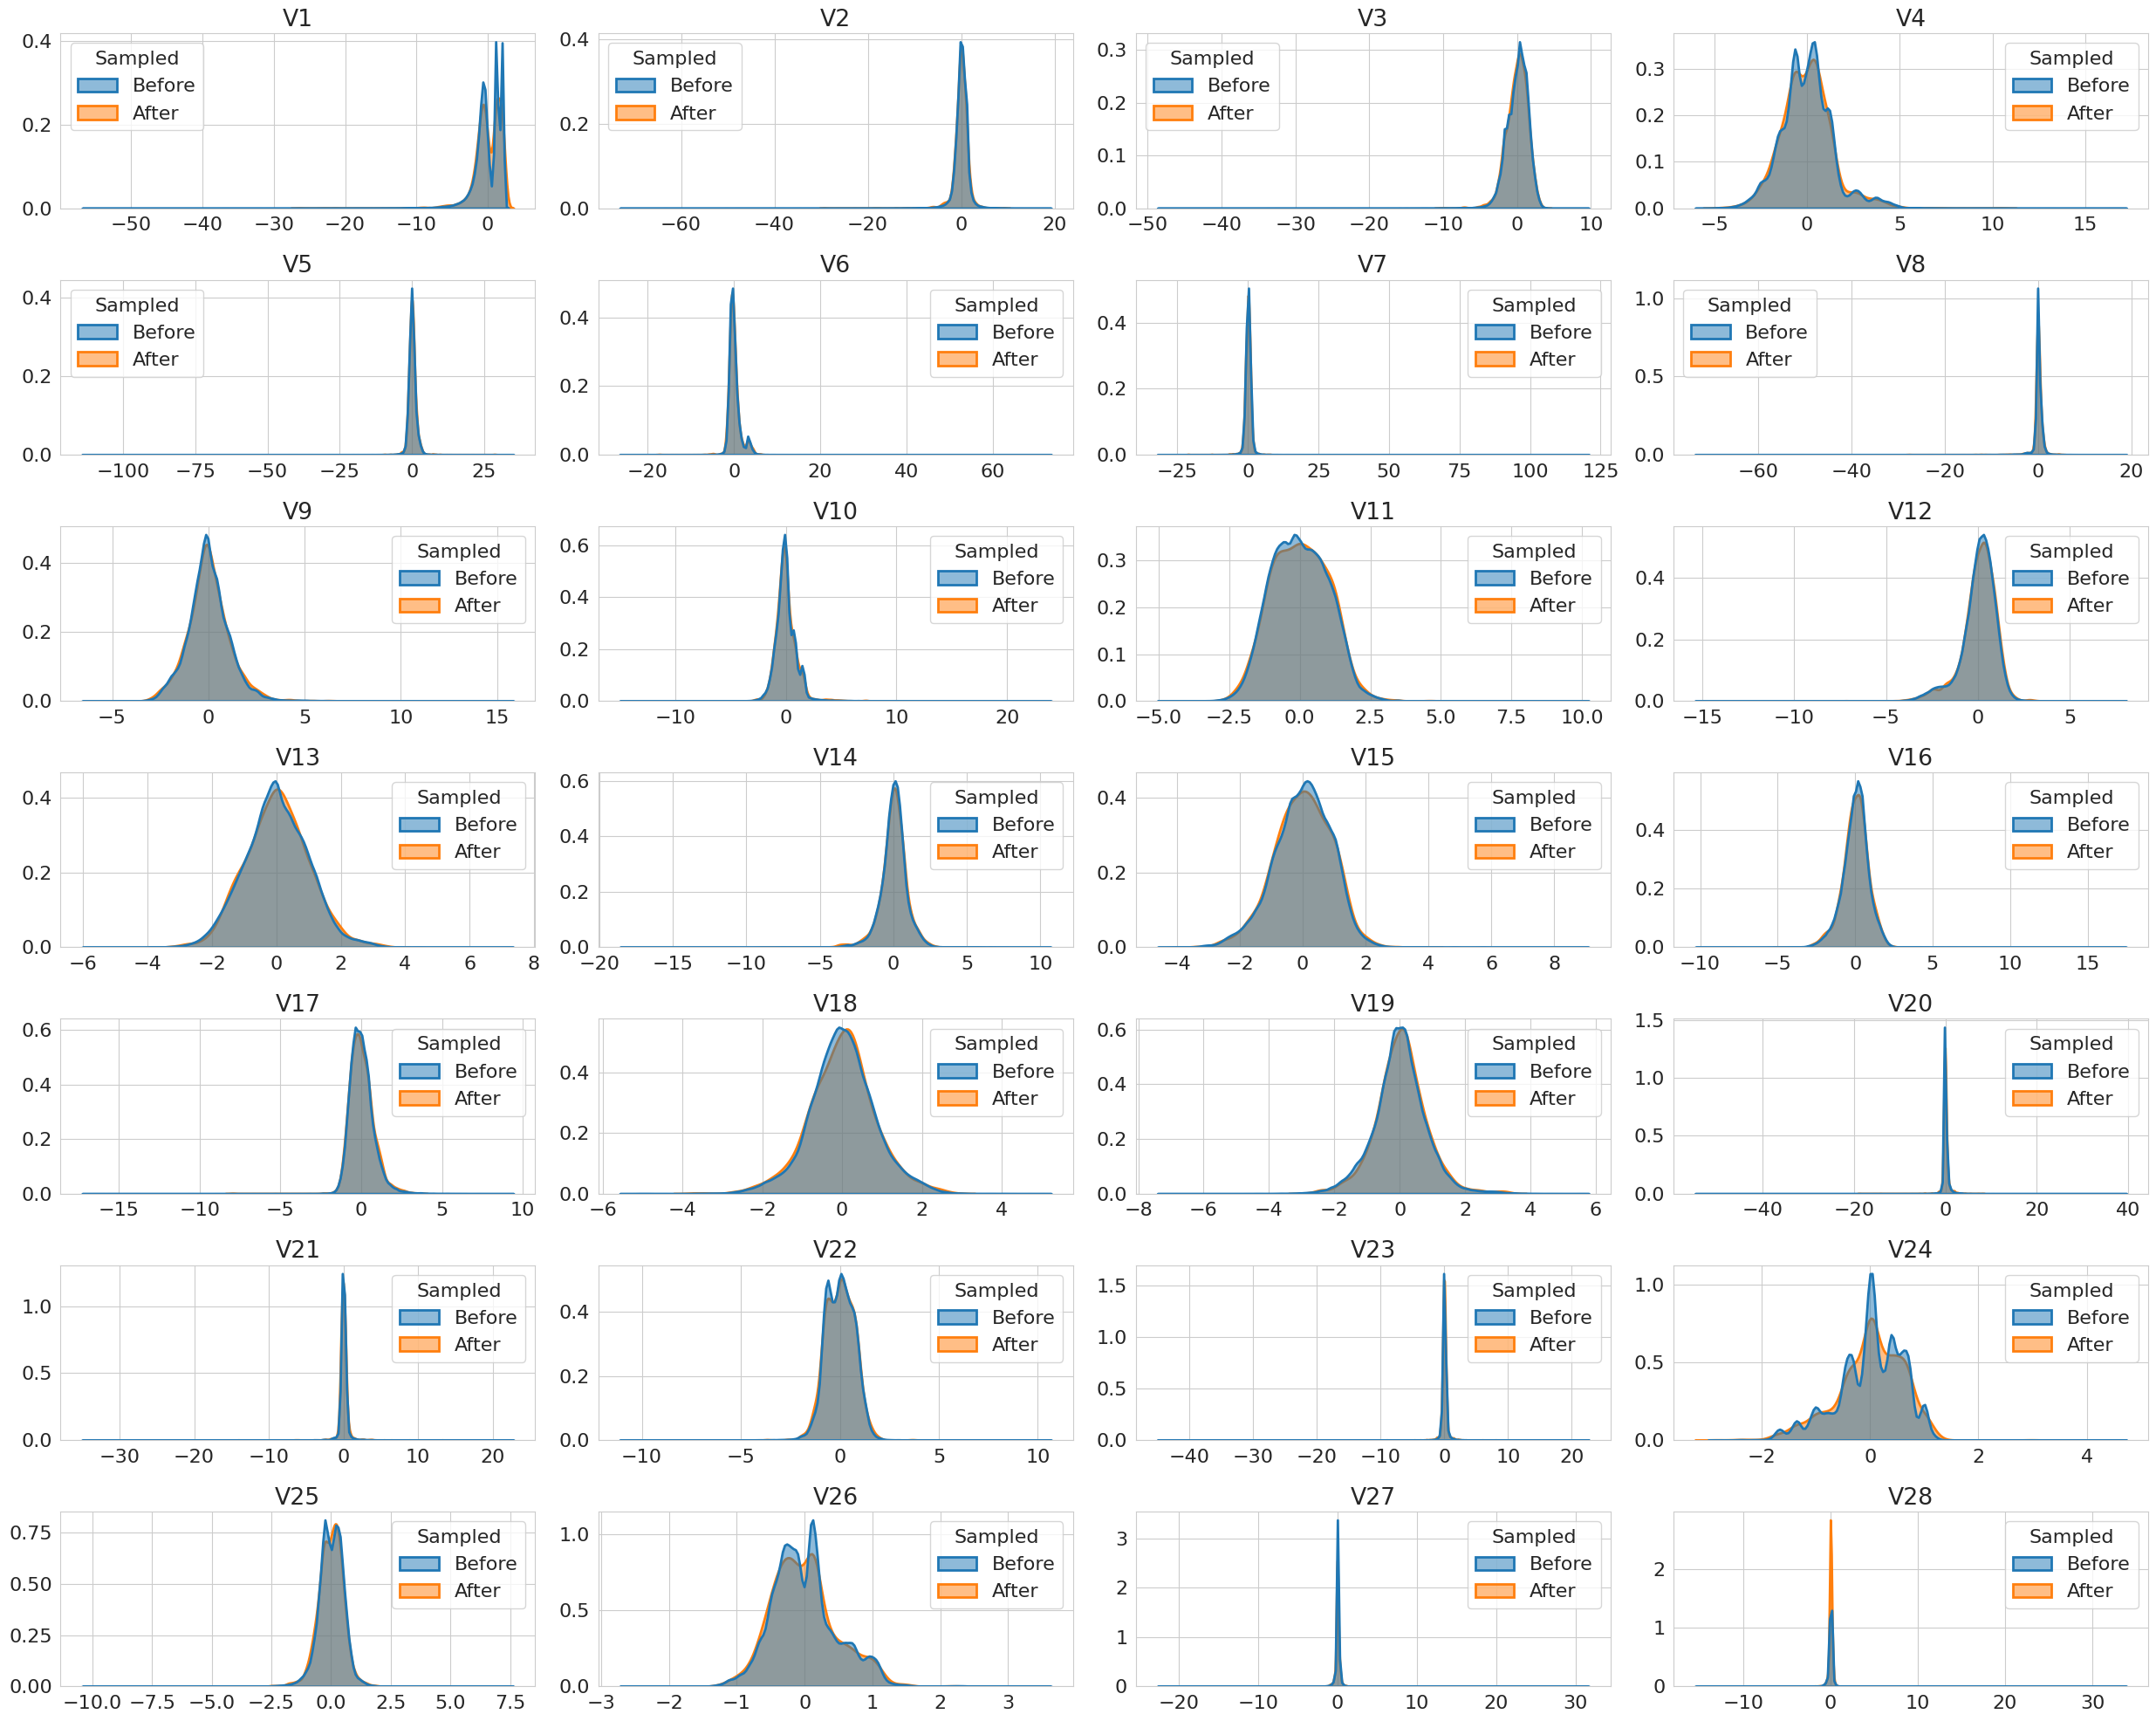

In [19]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.kdeplot(data=df_compare,
                x=col,
                hue="Sampled",
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,
                ax=axes[i])

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(col)

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_kde.png", dpi=300)
plt.show()

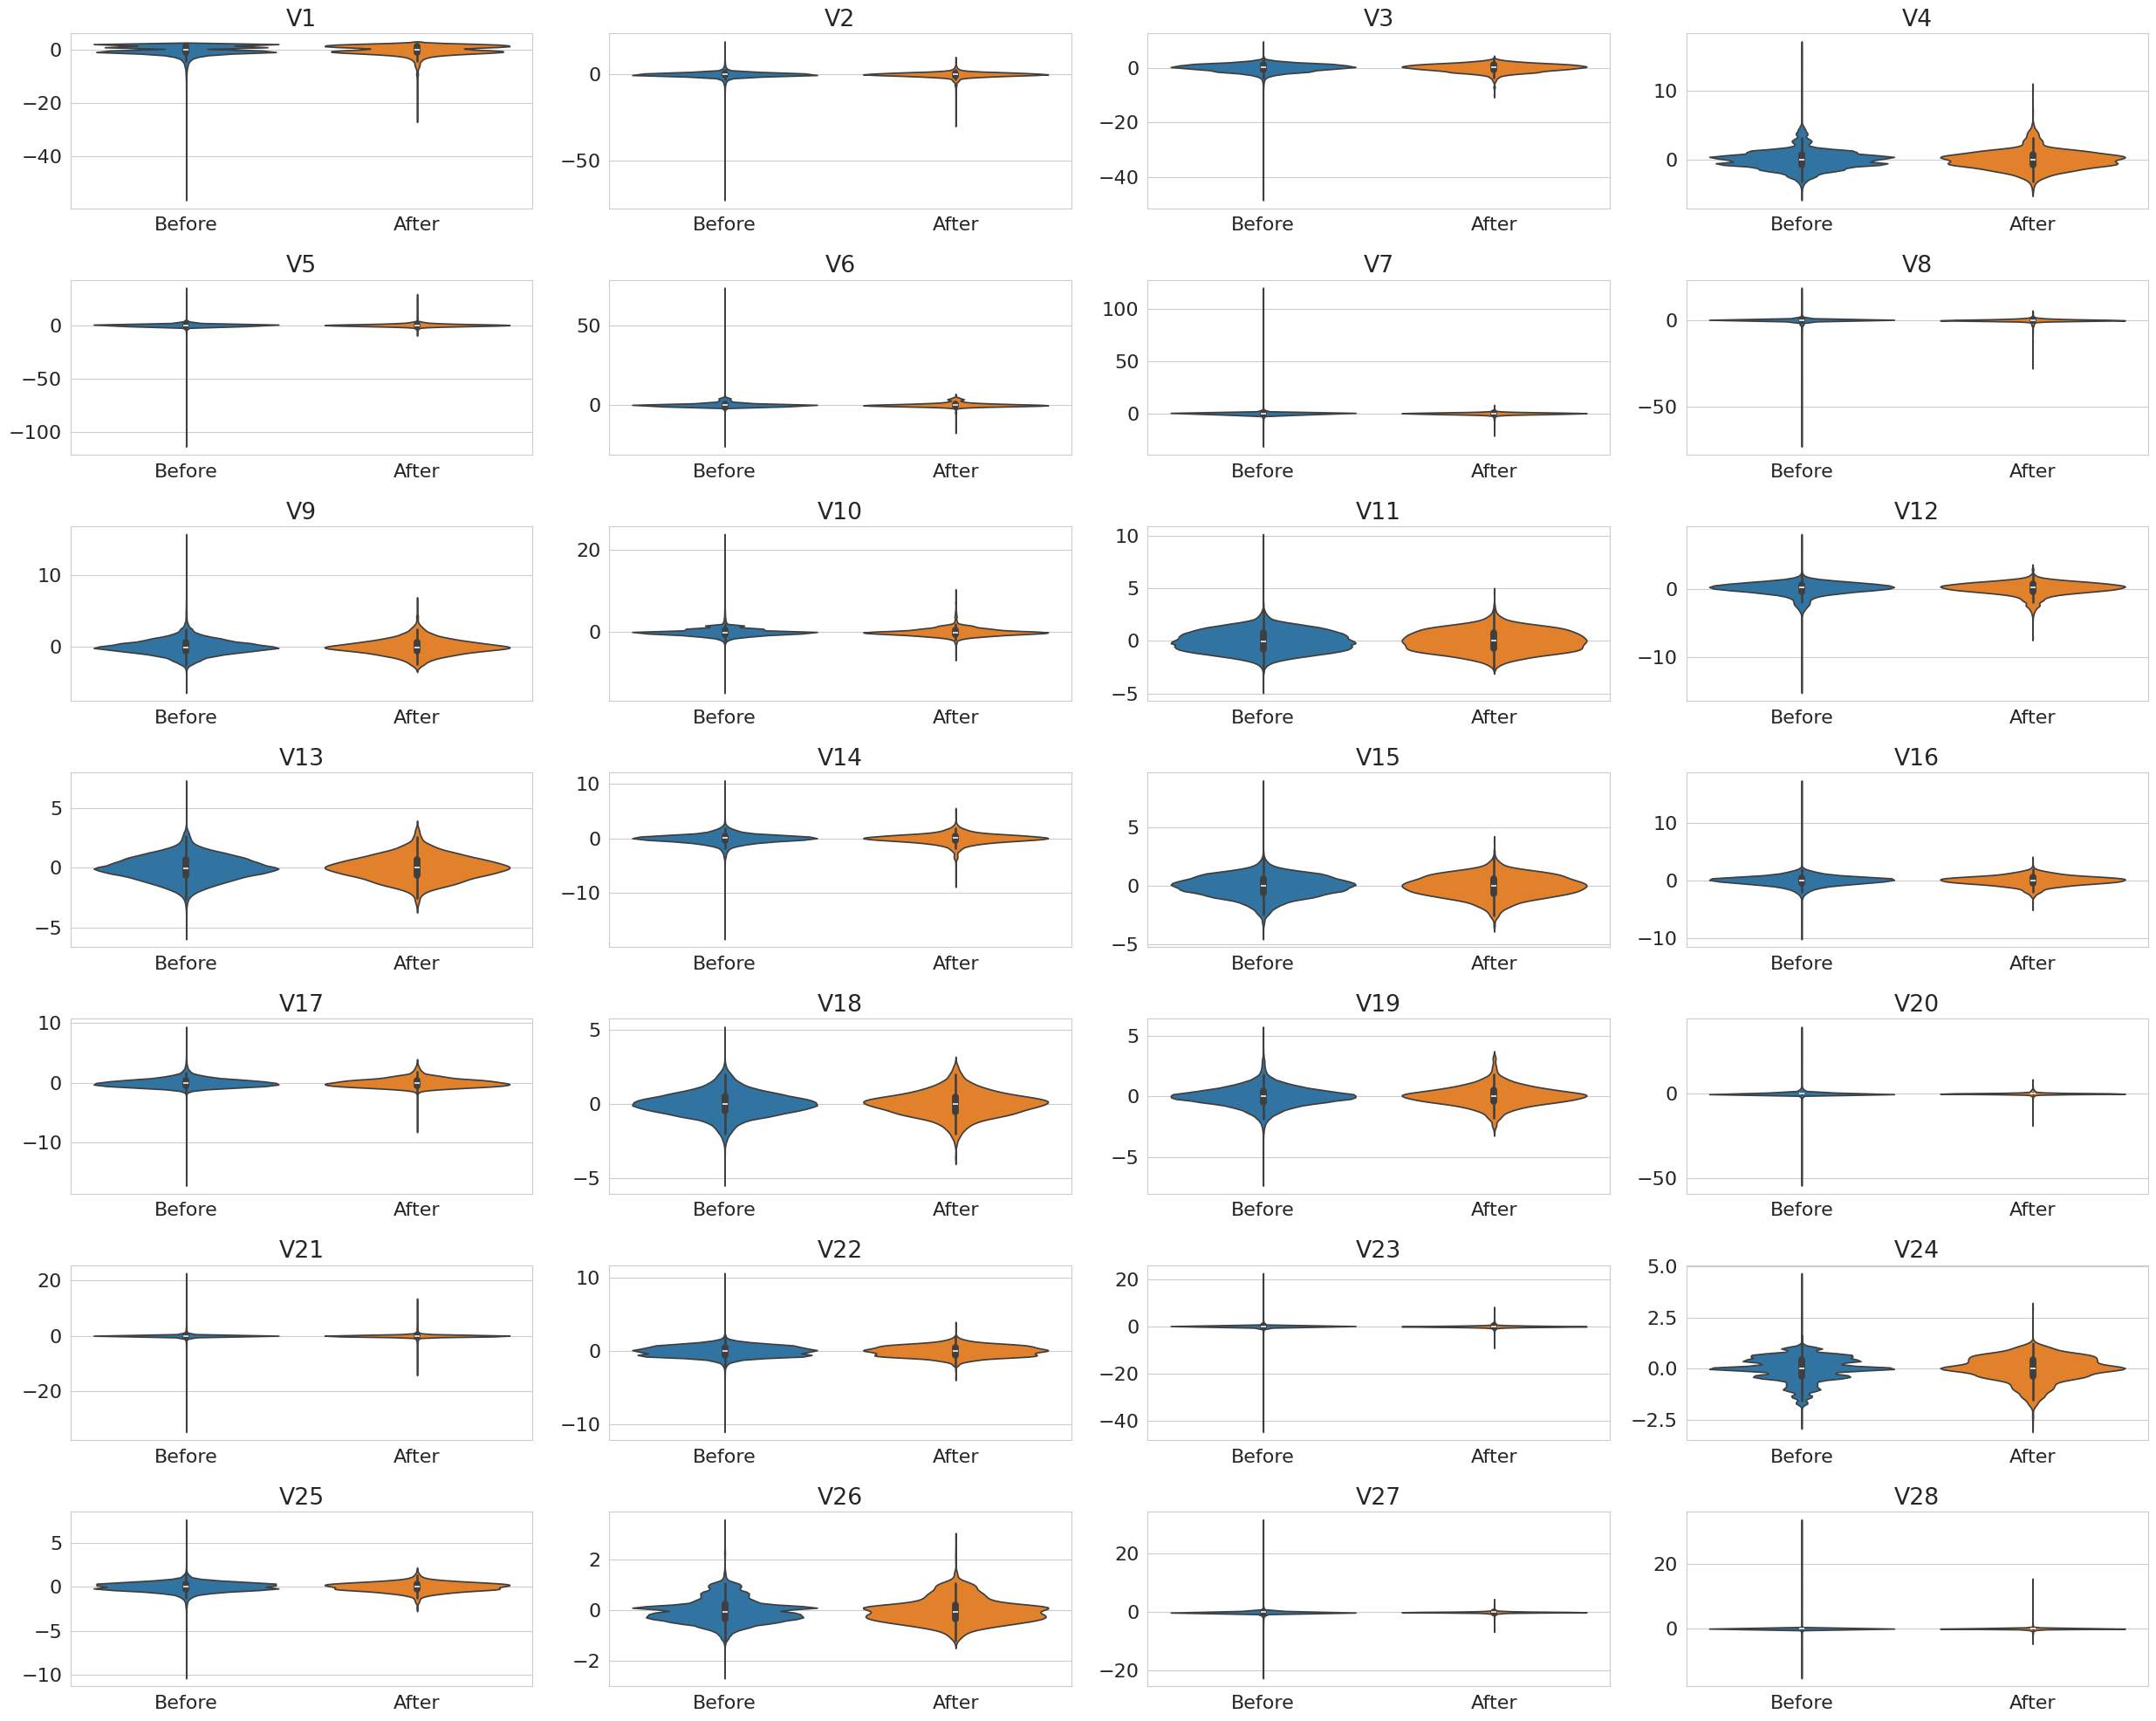

In [20]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.violinplot(data=df_compare,
                   x="Sampled",
                   y=col,
                   hue="Sampled",
                   ax=axes[i],
                   legend=False)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(col)

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_violin.png", dpi=300)
plt.show()

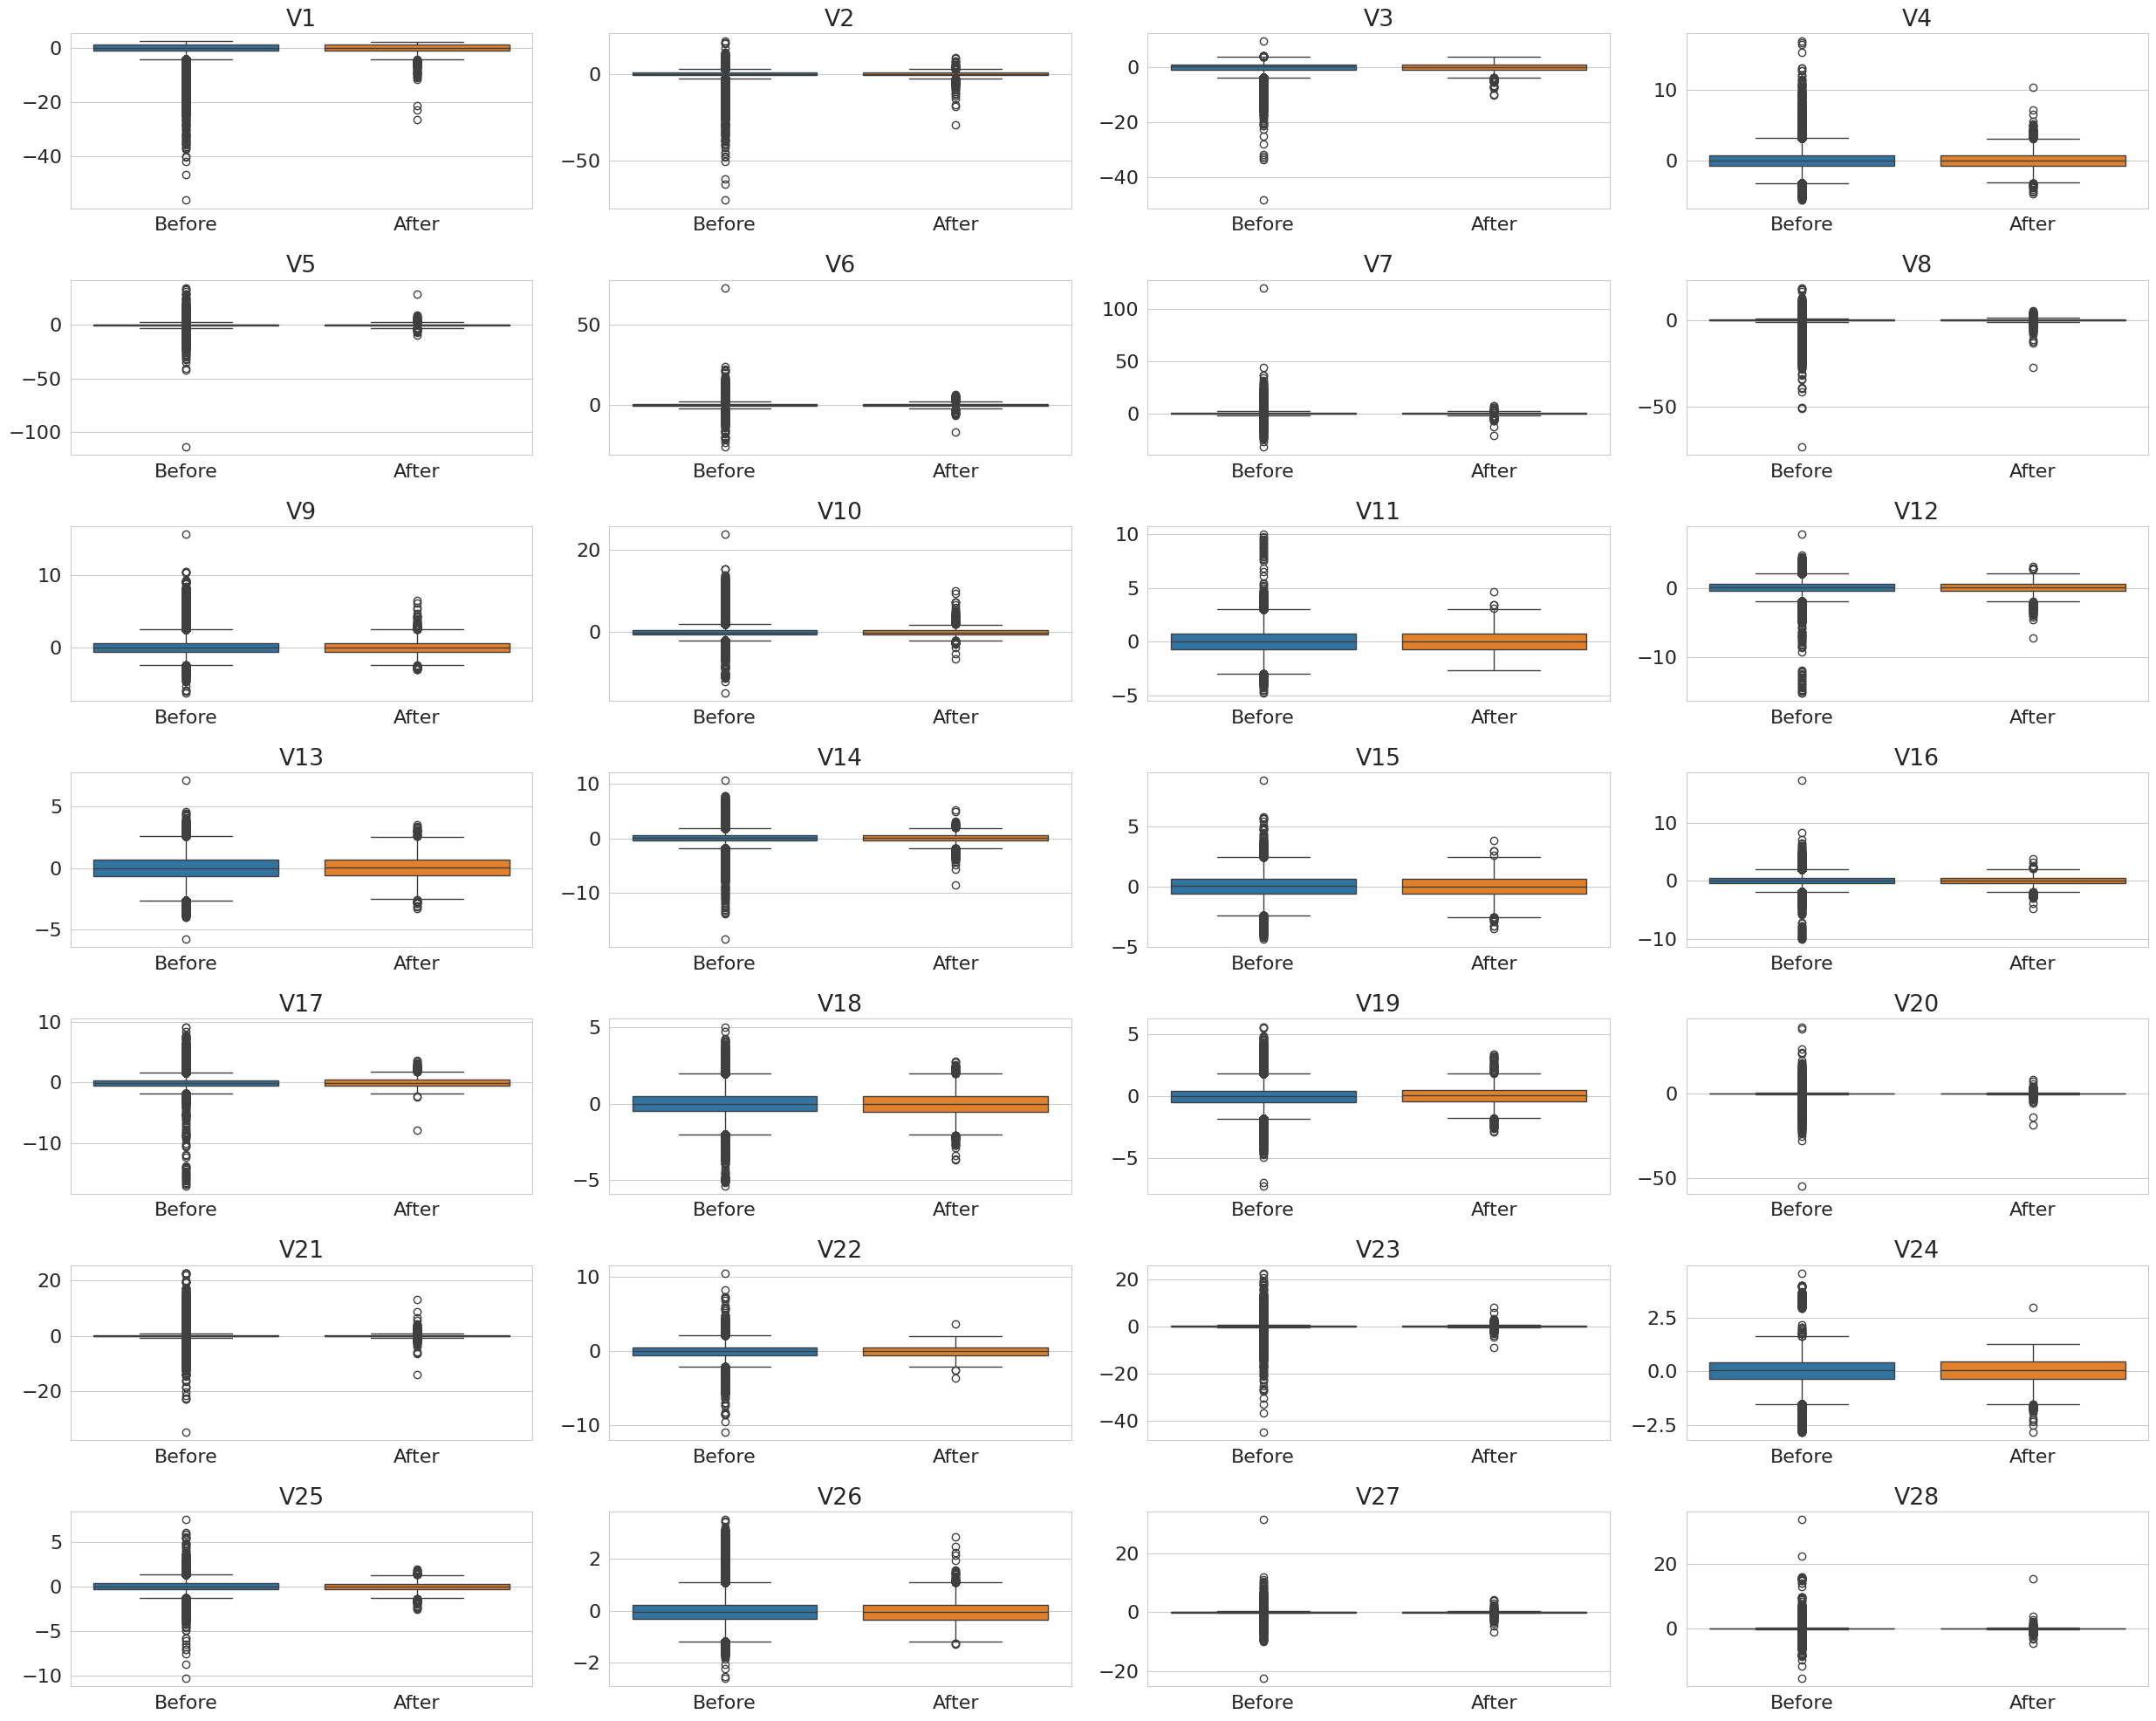

In [21]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.boxplot(data=df_compare,
                x="Sampled",
                y=col,
                hue="Sampled",
                ax=axes[i],
                legend=False)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(col)

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_boxplot.png", dpi=300)
plt.show()

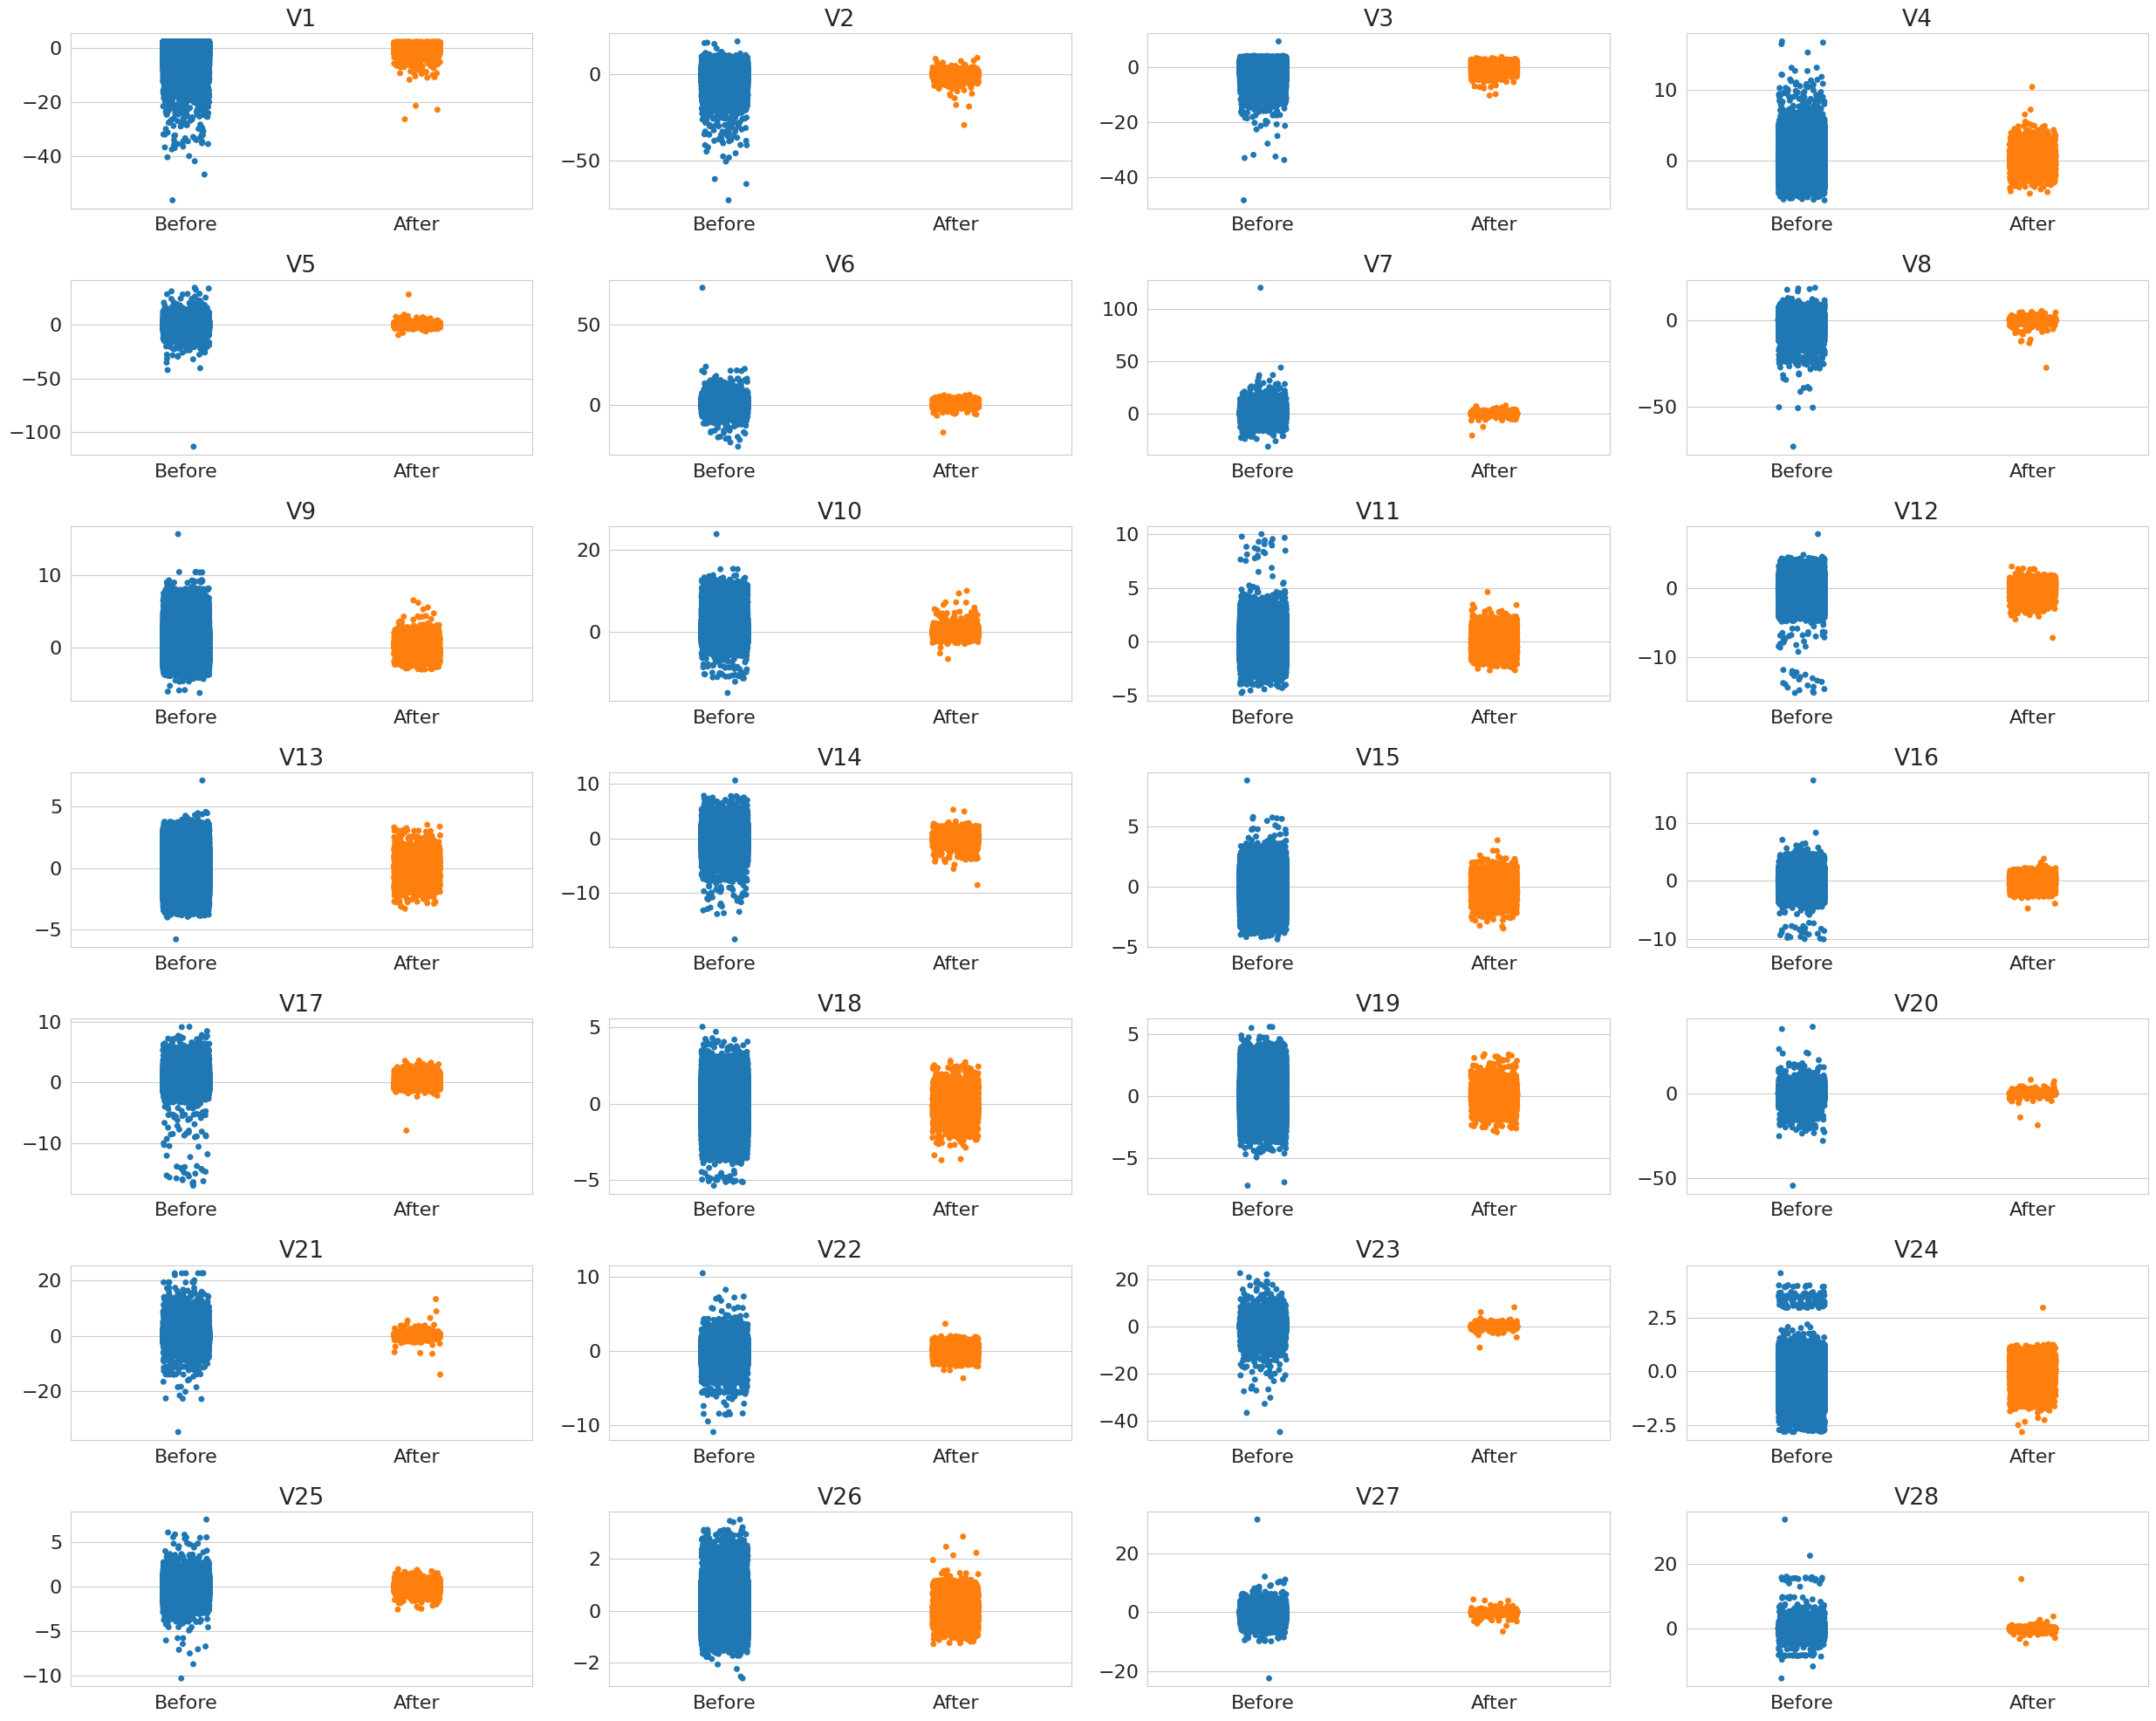

In [22]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.stripplot(data=df_compare,
                  x="Sampled",
                  y=col,
                  hue="Sampled",
                  ax=axes[i],
                  legend=False)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(col)

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_stripplot.png", dpi=300)
plt.show()

In [23]:
for _, col in enumerate(pcs_cols_name):
    out = ks_two_sample(df_compare[df_compare["Sampled"] == "Before"][col],
                        df_compare[df_compare["Sampled"] == "After"][col])

    print(f"{col:3} -- KS D={out['D']:.4f}, p={out['p']:.3e} (n_x={out['n_x']}, n_y={out['n_y']})")

V26 -- KS D=0.0169, p=4.808e-01 (n_x=284315, n_y=2460)
V27 -- KS D=0.0109, p=9.312e-01 (n_x=284315, n_y=2460)
V28 -- KS D=0.0109, p=9.292e-01 (n_x=284315, n_y=2460)


In every single one of your 28 variables, the p-value is greater than 0.05. This means that there is no statistically significant difference between the original dataset and the sample for any feature.

Even though all variables passed, we can see which ones the sampling captured most and least perfectly:
- Most Identical: V1 ($p=0.9939, D=0.0085$) and V22 ($p=0.9544, D=0.0103$). These are almost perfect matches.
- Most "Strained": V19 ($p=0.0686$) and V5 ($p=0.0832$). These have the highest D-statistics ($\approx 0.026$). While they are the "weakest" links, they still pass the 0.05 significance test, meaning even these variables are representative of the original.

## Correlation matrices

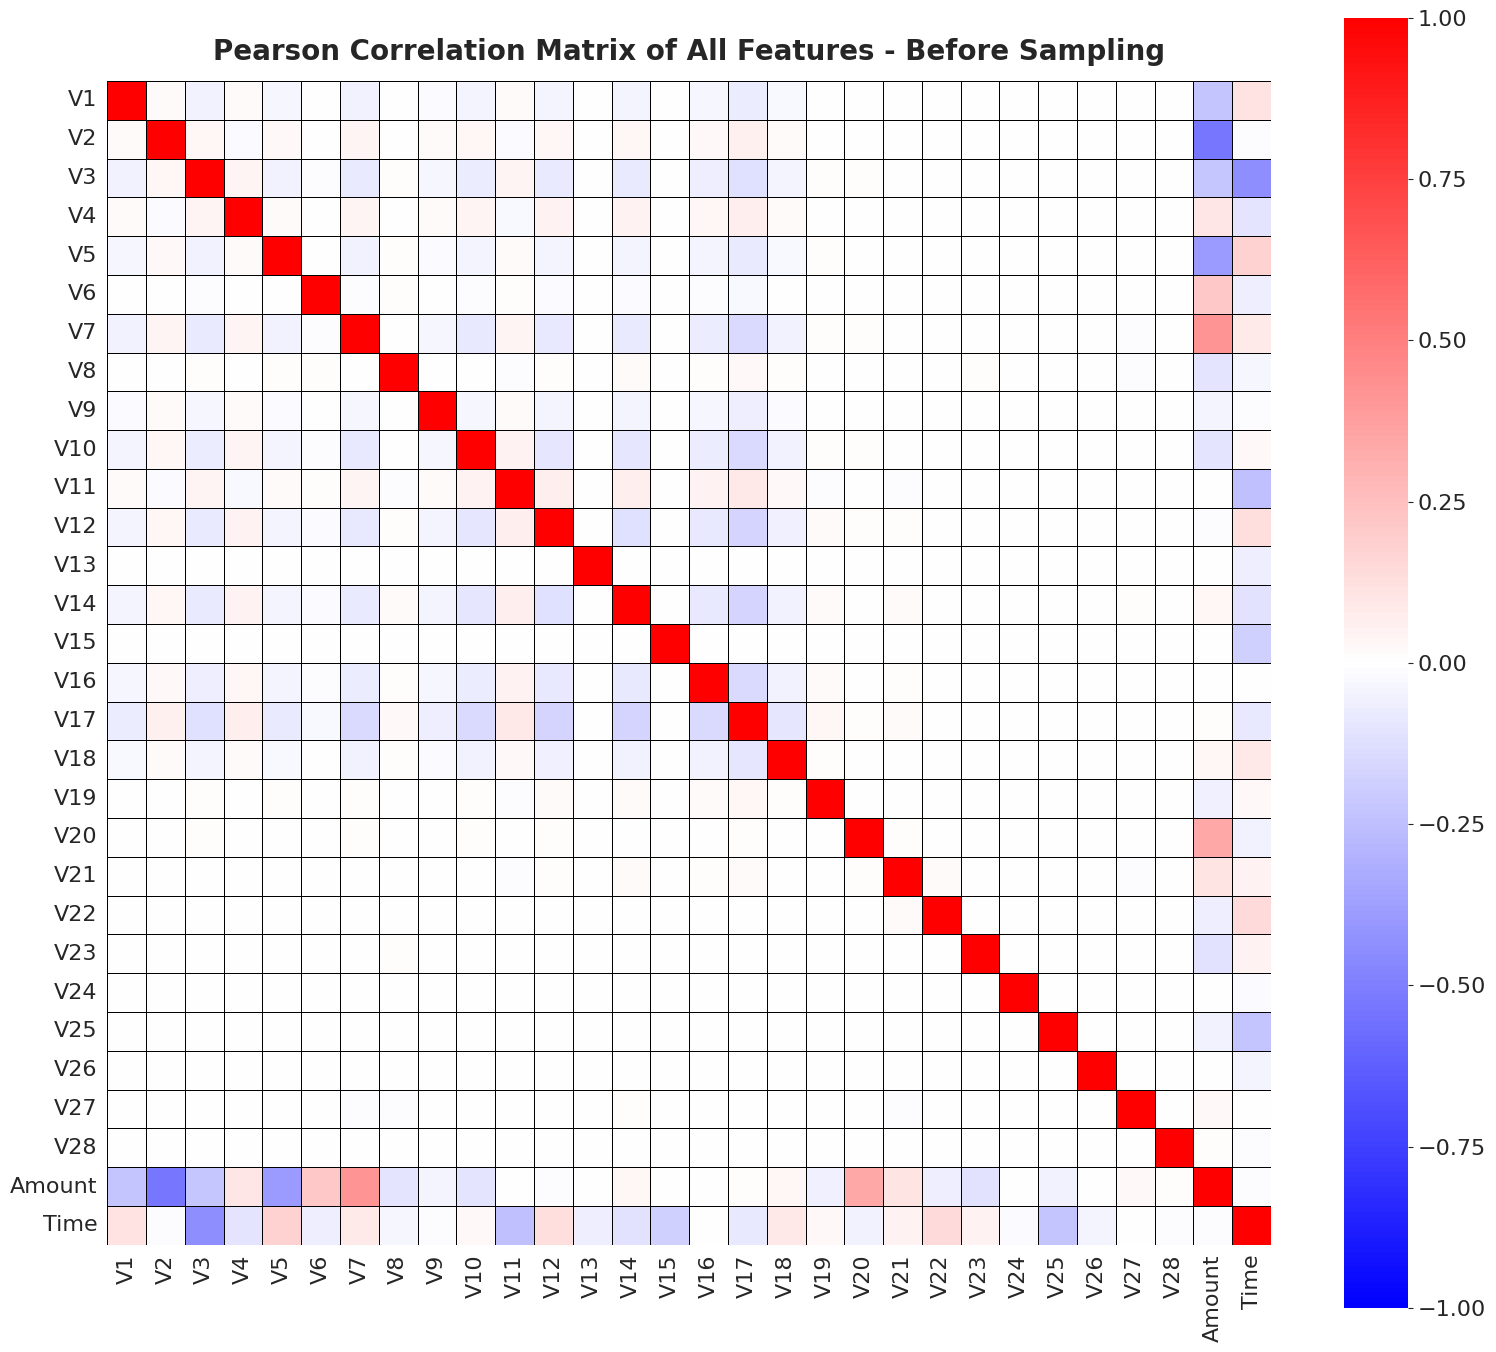

In [24]:
corr_before = df_compare.loc[df_compare["Sampled"] == "Before", pcs_cols_name + ["Amount", "Time"]].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_before,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of All Features - Before Sampling", fontsize=20, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_before.png", dpi=300)
plt.show()

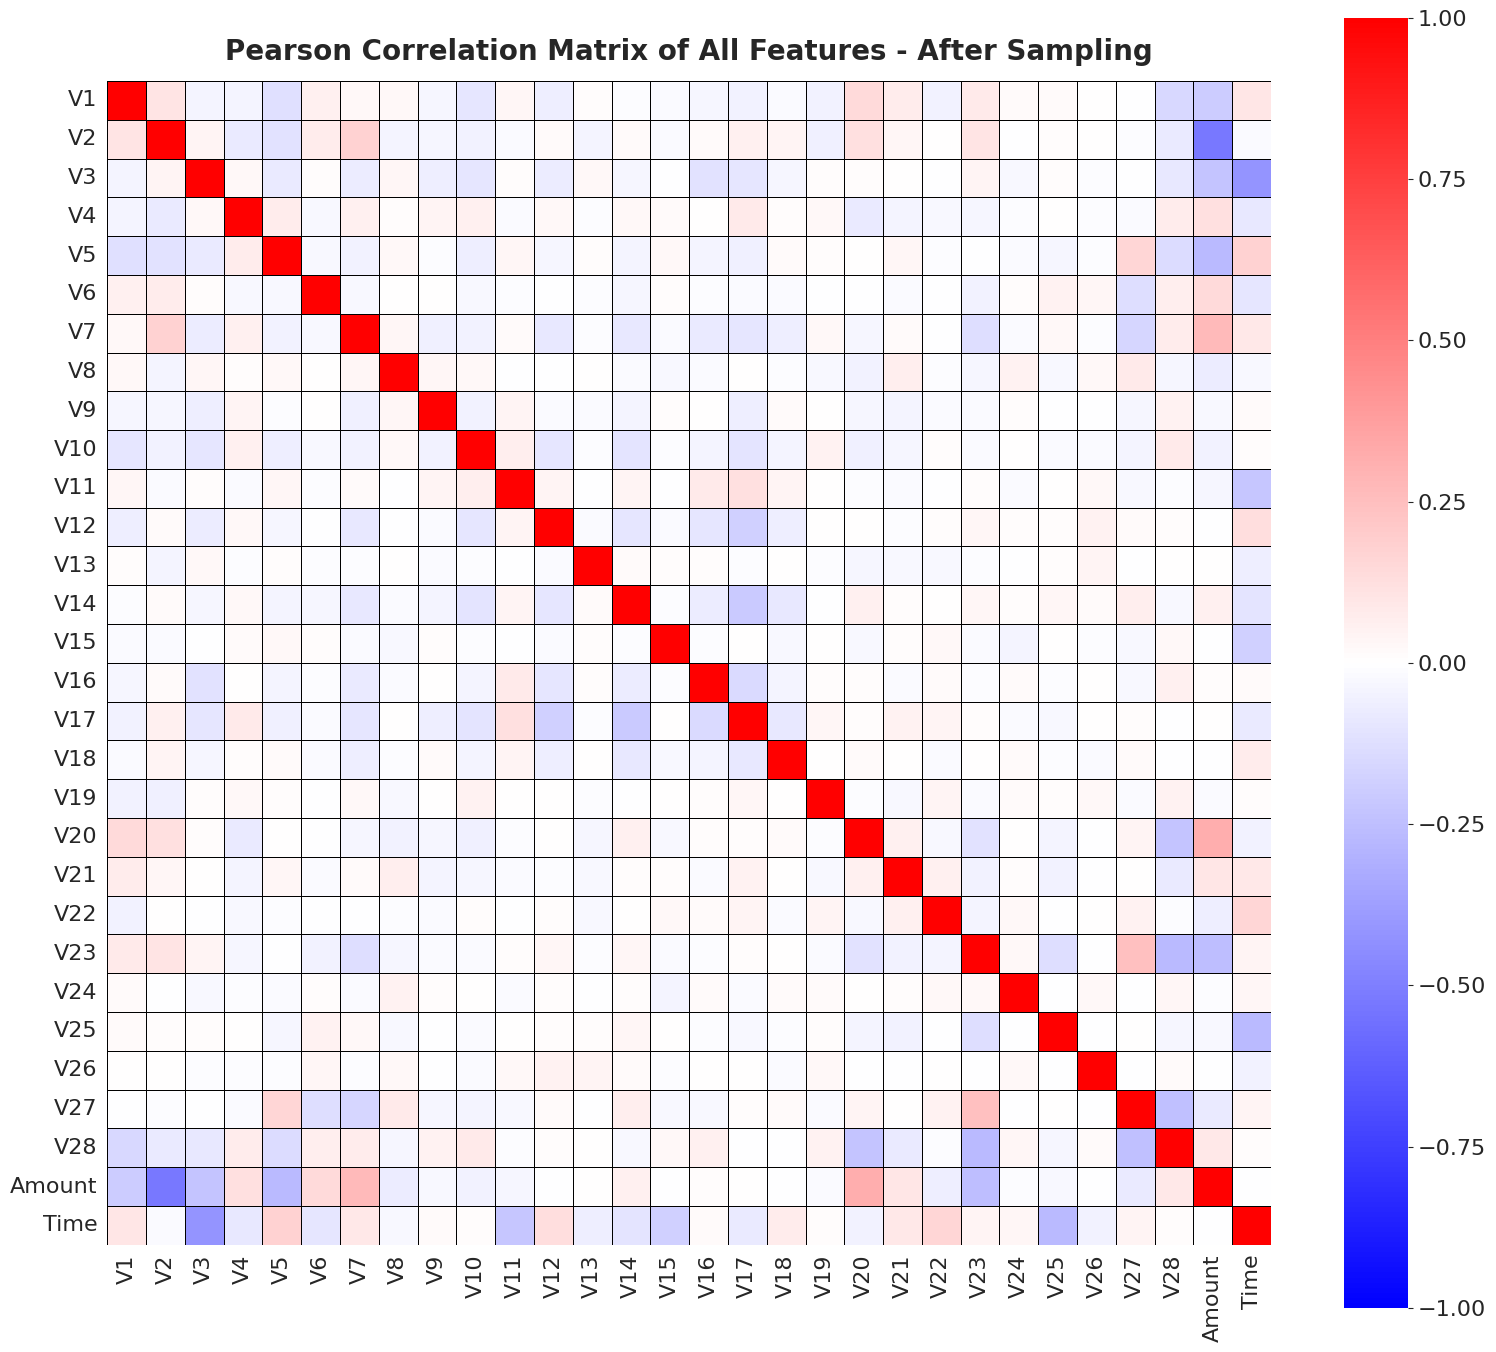

In [25]:
corr_after = df_compare.loc[df_compare["Sampled"] == "After", pcs_cols_name + ["Amount", "Time"]].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_after,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of All Features - After Sampling", fontsize=20, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_after.png", dpi=300)
plt.show()

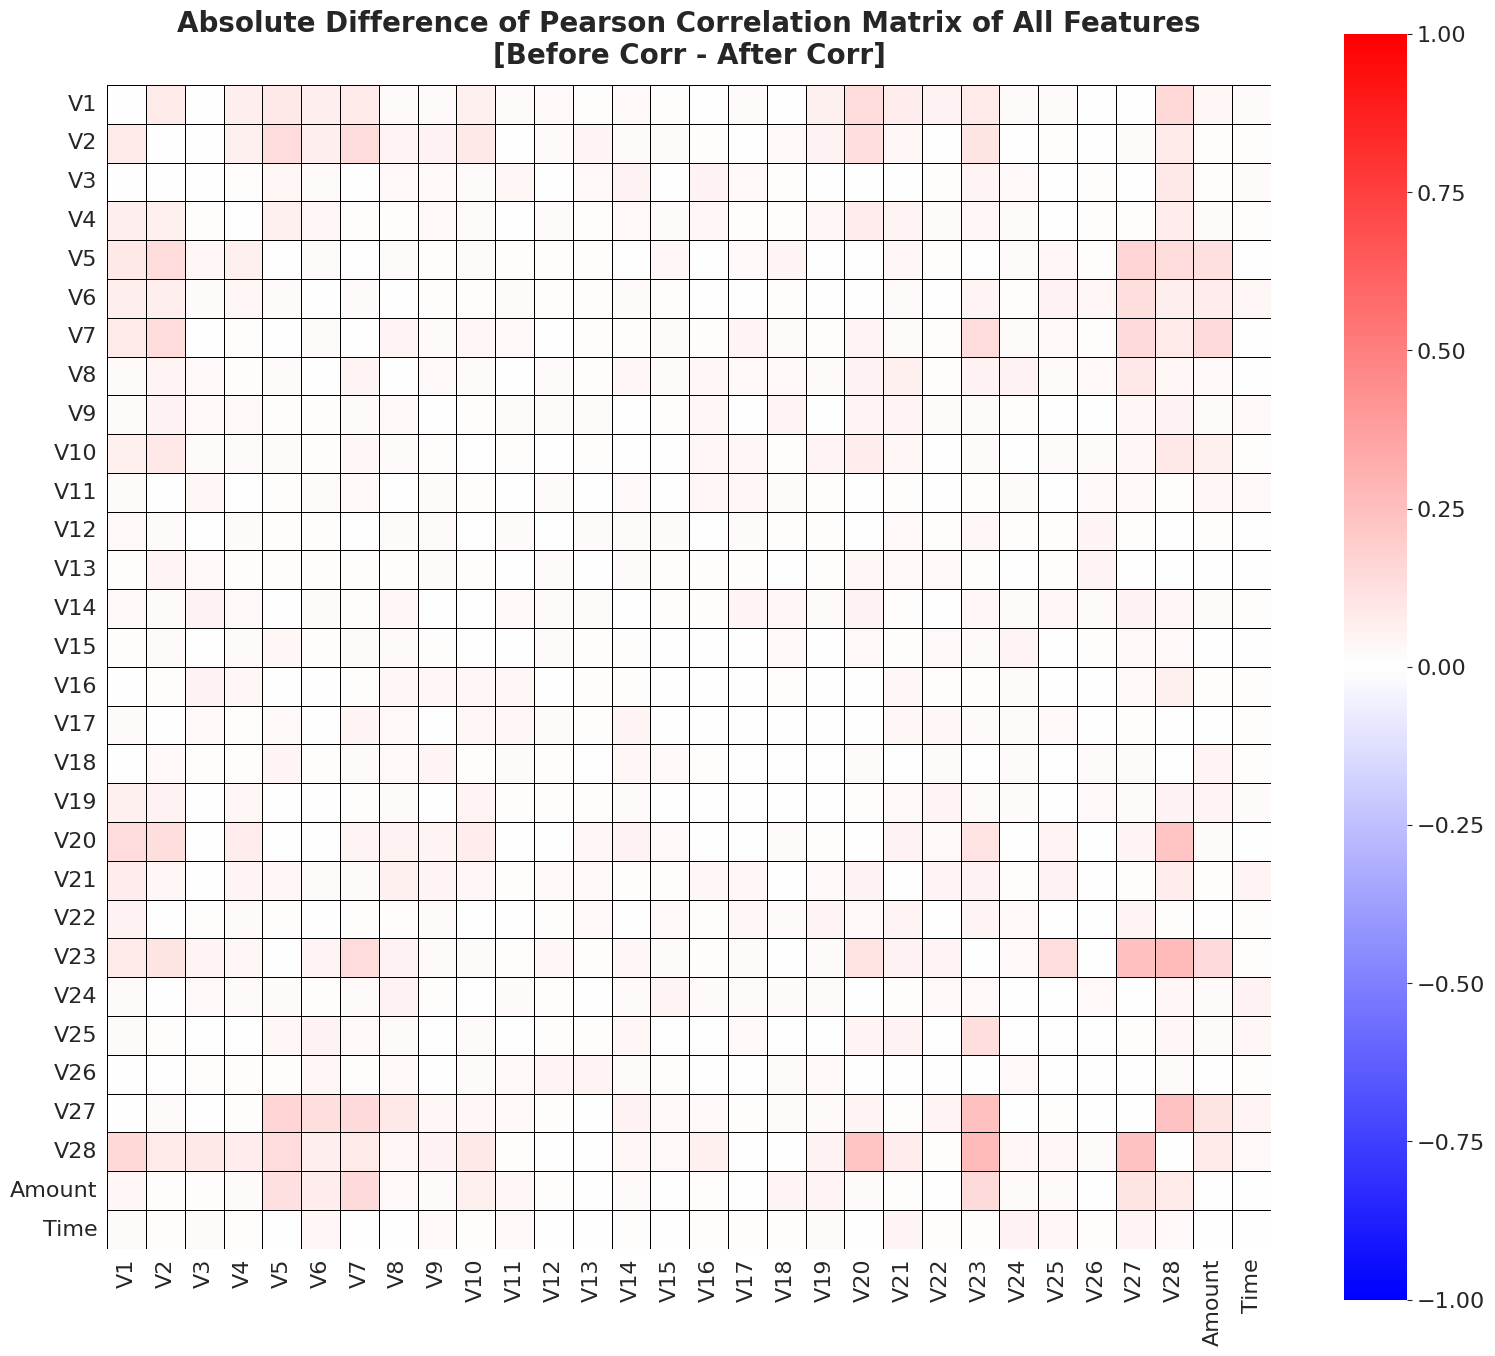

In [26]:
corr_diff = corr_before - corr_after
corr_diff_err = corr_diff.abs()
print(corr_diff_err.max().max())

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_diff_err,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Absolute Difference of Pearson Correlation Matrix of All Features\n[Before Corr - After Corr]", fontsize=20, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_abs_error_diff.png", dpi=300)
plt.show()